In [1]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from matplotlib.animation import FuncAnimation, PillowWriter
import os
from jax import random
from jax import grad, jit, vmap
from IPython.display import Image
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
import jax.random as random
# Set JAX to use CPU backend to avoid device placement issues
jax.config.update("jax_platform_name", "cpu")

W0000 00:00:1776904442.120447 19510479 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1776904442.180134 19510479 service.cc:145] XLA service 0x17ae90ed0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776904442.180178 19510479 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1776904442.183797 19510479 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1776904442.183824 19510479 mps_client.cc:384] XLA backend will use up to 12712640512 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M3

systemMemory: 16.00 GB
maxCacheSize: 5.92 GB



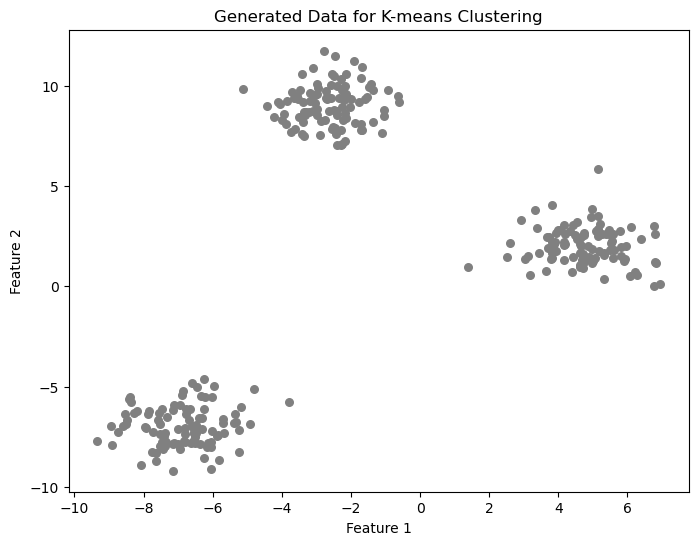

In [2]:
# Generate synthetic dataset
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
X = jnp.array(X)
plt.figure(figsize=(8, 6))
plt.scatter(np.array(X[:, 0]), np.array(X[:, 1]), c='gray', s=30)
plt.title("Generated Data for K-means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [3]:
key = random.PRNGKey(42)
# Update centroids using masking
def compute_new_centroid(k, centroids, labels, X):
    mask = labels == k
    cluster_points = X * mask[:, None]
    cluster_sum = jnp.sum(cluster_points, axis=0)
    cluster_count = jnp.sum(mask)
    return jnp.where(cluster_count > 0, cluster_sum / cluster_count, centroids[k])


def kmeans_jax(X, n_clusters=3, max_iter=10, key=key):
    n_samples, n_features = X.shape
    # Randomly initialize centroids
    idx = jax.random.choice(key, n_samples, (n_clusters,), replace=False)
    centroids = X[idx]
    history = []

    for i in range(max_iter):
        # Compute distances and assign clusters
        dists = jnp.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = jnp.argmin(dists, axis=1)
        history.append((centroids, labels))

        # Update centroids using vmap
        new_centroids = jax.vmap(lambda k: compute_new_centroid(k, centroids, labels, X))(jnp.arange(n_clusters))

        # Check for convergence
        if jnp.all(jnp.linalg.norm(new_centroids - centroids, axis=1) < 1e-4):
            print(f"Converged after {i} iterations.")
            break
        centroids = new_centroids

    return centroids, labels, history

Converged after 4 iterations.


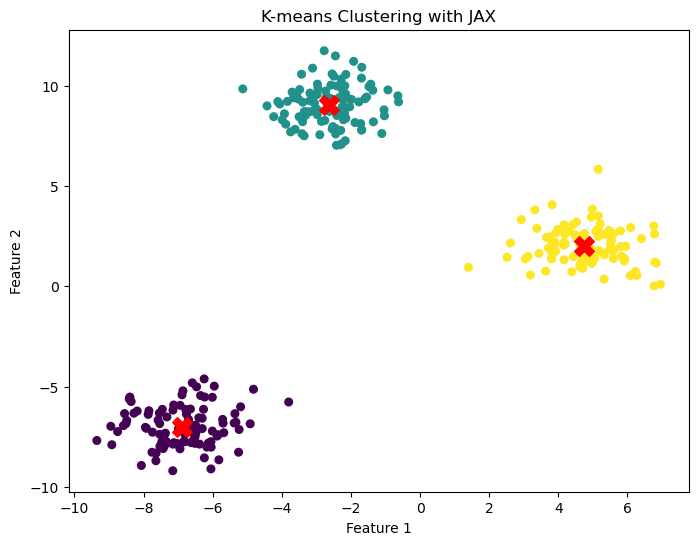

In [4]:
centroids, labels, history = kmeans_jax(X, n_clusters=3, max_iter=10, key=key)

plt.figure(figsize=(8, 6))
plt.scatter(np.array(X[:, 0]), np.array(X[:, 1]), c=np.array(labels), cmap='viridis', s=30)
plt.scatter(np.array(centroids[:, 0]), np.array(centroids[:, 1]), s=200, c='red', marker='X')
plt.title("K-means Clustering with JAX")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

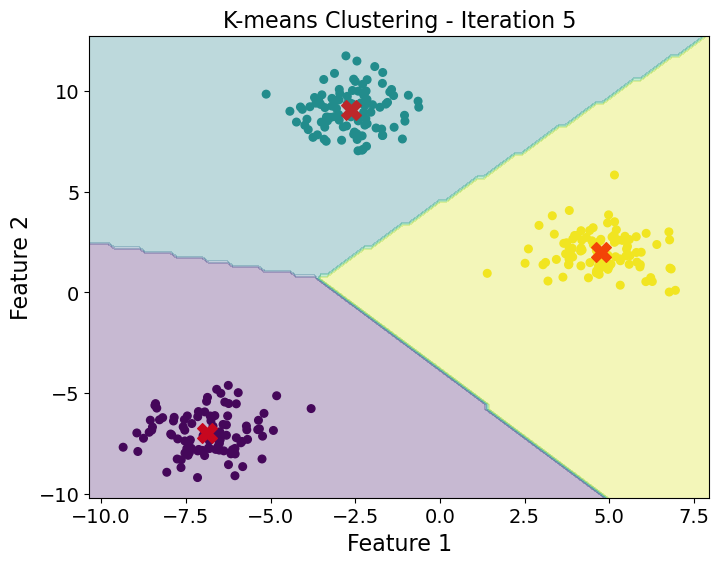

In [5]:
# Plotting the K-means clustering process with decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))

# Initialize the scatter plot and centroid markers
scatter = ax.scatter(np.array(X[:, 0]), np.array(X[:, 1]), c='gray', s=30)
centroid_scatter = ax.scatter([], [], s=200, c='red', marker='X')

# Initialize the animation
def init():
    scatter.set_array(np.zeros(X.shape[0]))
    centroid_scatter.set_offsets(np.zeros((len(history[0][0]), 2)))
    return scatter, centroid_scatter

# Update function for the animation
def update(frame):
    centroids, labels = history[frame]
    ax.clear()
    scatter = ax.scatter(np.array(X[:, 0]), np.array(X[:, 1]), c=np.array(labels), cmap='viridis', s=30)
    centroid_scatter = ax.scatter(np.array(centroids[:, 0]), np.array(centroids[:, 1]), s=200, c='red', marker='X')
    
    # Create a mesh grid for decision boundaries
    x_min, x_max = np.array(X[:, 0]).min() - 1, np.array(X[:, 0]).max() + 1
    y_min, y_max = np.array(X[:, 1]).min() - 1, np.array(X[:, 1]).max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = jnp.c_[xx.ravel(), yy.ravel()]
    
    # Compute distances and assign clusters for the grid points
    dists = jnp.linalg.norm(grid[:, None, :] - centroids[None, :, :], axis=2)
    grid_labels = jnp.argmin(dists, axis=1)
    grid_labels = grid_labels.reshape(xx.shape)
    
    # Plot decision boundaries
    ax.contourf(xx, yy, np.array(grid_labels), alpha=0.3, cmap='viridis')
    
    ax.set_title(f"K-means Clustering - Iteration {frame + 1}", fontsize=16)
    ax.set_xlabel("Feature 1", fontsize=16)
    ax.set_ylabel("Feature 2", fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    return scatter, centroid_scatter

# Create the animation
ani = FuncAnimation(fig, update, frames=len(history), init_func=init, blit=False, interval=1000)

# Save the animation as a GIF
ani.save("kmeans_animation_with_boundaries.gif", writer=PillowWriter(fps=2))


In [8]:
class GMMVisualizerJAX:
    """
    Gaussian Mixture Model clustering with visualization of the process using JAX.
    """
    def __init__(self, X, n_components=3, max_iter=10, key=None):
        self.X = X
        self.n_components = n_components
        self.max_iter = max_iter
        self.n_samples, self.n_features = X.shape
        if key is None:
            key = random.PRNGKey(0)
        idx = random.choice(key, self.n_samples, (n_components,), replace=False)
        self.means = X[idx]
        self.covariances = jnp.stack([jnp.cov(X.T)] * n_components)
        self.weights = jnp.ones(n_components) / n_components
        self.responsibilities = jnp.zeros((self.n_samples, n_components))
        self.history = []

    def multivariate_normal_pdf(self, X, mean, cov):
        """Compute multivariate normal pdf for all X."""
        n = X.shape[1]
        diff = X - mean
        inv_cov = jnp.linalg.inv(cov)
        det_cov = jnp.linalg.det(cov)
        norm_const = 1.0 / (jnp.power((2 * jnp.pi), n / 2) * jnp.sqrt(det_cov))
        exp_term = jnp.exp(-0.5 * jnp.sum(diff @ inv_cov * diff, axis=1))
        return norm_const * exp_term

    def e_step(self):
        """E-step: update responsibilities."""
        pdfs = []
        for k in range(self.n_components):
            pdfs.append(self.weights[k] * self.multivariate_normal_pdf(self.X, self.means[k], self.covariances[k]))
        pdfs = jnp.stack(pdfs, axis=1)
        responsibilities = pdfs / jnp.sum(pdfs, axis=1, keepdims=True)
        self.responsibilities = responsibilities
        self.history.append((
            self.means.copy(), 
            self.covariances.copy(), 
            self.weights.copy(), 
            self.responsibilities.copy()
        ))

    def m_step(self):
        """M-step: update means, covariances, weights."""
        N_k = jnp.sum(self.responsibilities, axis=0)
        self.weights = N_k / self.n_samples
        self.means = (self.responsibilities.T @ self.X) / N_k[:, None]
        covariances = []
        for k in range(self.n_components):
            diff = self.X - self.means[k]
            weighted = diff.T * self.responsibilities[:, k]
            cov = weighted @ diff / N_k[k]
            covariances.append(cov)
        self.covariances = jnp.stack(covariances)

    def fit(self):
        for _ in range(self.max_iter):
            self.e_step()
            self.m_step()

    def animate(self, filename="gmm_jax_animation.gif"):
        fig, ax = plt.subplots(figsize=(8, 6))

        def plot_ellipse(mean, cov, ax, color):
            vals, vecs = np.linalg.eigh(np.array(cov))
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
            width, height = 2 * np.sqrt(vals)
            ellipse = Ellipse(mean, width, height, theta, edgecolor=color, lw=2, facecolor='none')
            ax.add_patch(ellipse)

        def update(frame):
            ax.clear()
            means, covariances, weights, responsibilities = self.history[frame]
            resp_colors = np.argmax(np.array(responsibilities), axis=1)
            max_resp = np.max(np.array(responsibilities), axis=1)
            # Color by responsibility (soft coloring)
            colors = sns.color_palette("viridis", self.n_components)
            point_colors = np.array([colors[i] for i in resp_colors])
            ax.scatter(np.array(self.X[:, 0]), np.array(self.X[:, 1]), c=point_colors, s=30, alpha=max_resp)
            for k in range(self.n_components):
                # Fix: Ellipse expects (xy, width, height, angle) as keywords, not as positional arguments
                mean = means[k]
                width, height = 2 * np.sqrt(np.linalg.eigvalsh(covariances[k]))
                # Compute the angle of the ellipse from the eigenvectors of the covariance matrix
                eigvals, eigvecs = np.linalg.eigh(np.array(covariances[k]))
                order = eigvals.argsort()[::-1]
                eigvals, eigvecs = eigvals[order], eigvecs[:, order]
                theta = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
                color = colors[k]
                ellipse = Ellipse(xy=mean, width=width, height=height, angle=theta, edgecolor=color, lw=2, facecolor='none')
                ax.add_patch(ellipse)
                ax.scatter(means[k][0], means[k][1], c=[colors[k]], s=200, marker='X', edgecolor='k')
            ax.set_title(f"Gaussian Mixture Model - Iteration {frame + 1}", fontsize=16)
            ax.set_xlabel("Feature 1", fontsize=16)
            ax.set_ylabel("Feature 2", fontsize=16)

            ax.set_xlim(np.array(self.X[:, 0]).min() - 2, np.array(self.X[:, 0]).max() + 2)
            ax.set_ylim(np.array(self.X[:, 1]).min() - 2, np.array(self.X[:, 1]).max() + 2)
            ax.tick_params(axis='both', which='major', labelsize=14)

        ani = FuncAnimation(fig, update, frames=len(self.history), interval=1000, blit=False)
        ani.save(filename, writer=PillowWriter(fps=2))
        plt.close(fig)
        return filename

# Usage:
gmm_vis = GMMVisualizerJAX(X, n_components=3, max_iter=20, key=key)
gmm_vis.fit()
gmm_vis.animate("gmm_jax_animation.gif")

'gmm_jax_animation.gif'

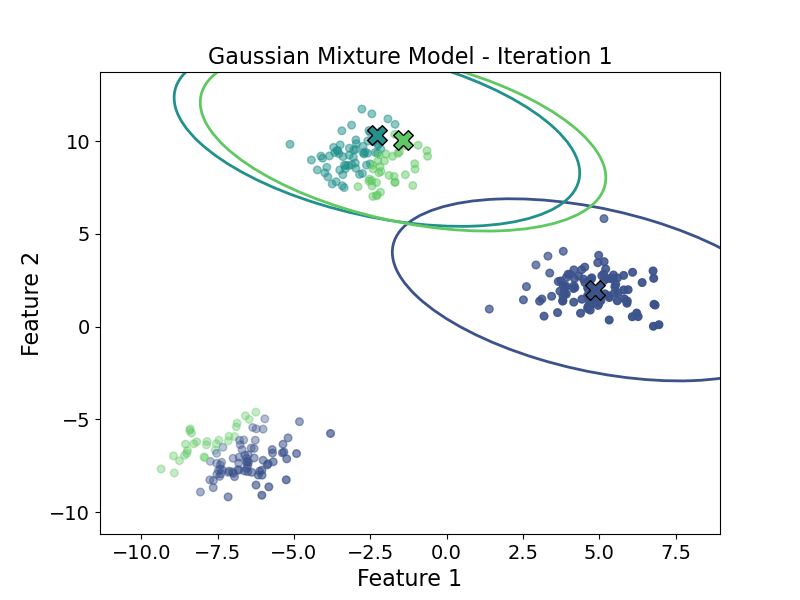

In [9]:
Image(filename="gmm_jax_animation.gif")